Here, we use the GINCO and EN-GINCO datasets that have been fully annotated by 2 annotators. We apply the best-performing GPT models (see the AGILE benchmark) on the datasets and compare their agreement with the annotators with the agreement between the annotators.

Use the emma_main kernel

In [3]:
import pandas as pd
import json
import numpy as np
import tarfile
import os
from collections import Counter
import matplotlib.pyplot as plt
from time import sleep
from sklearn.model_selection import train_test_split
from openai import OpenAI
from tqdm import tqdm
client = OpenAI(api_key=open('key.txt').read())

In [ ]:
# Open the dataset
ginco = pd.read_json("datasets/final_ginco_with_annotators_labels.jsonl", 
lines=True)
print(ginco.shape)
ginco.head(3)

(725, 11)


,id,hard,Slovene_text,primary_level_1,MT_text,split,Taja,Mojca,Ann1,Ann2,Gold_X-GENRE
0,3726,False,JEDILNIK <p/> Iskalnik <p/> Poglavitni cilj pr...,Information/Explanation,JEDILNIK <p/> Search <p/> The main objective o...,train,Information/Explanation,Information/Explanation,Information/Explanation,Information/Explanation,Information/Explanation
1,5621,False,Projekt INNOVAge in zavod Oreli <p/> Zavod Ore...,Promotion of Services,Project INNOVAge and the Oreli Institute <p/> ...,train,Promotion of Services,Information/Explanation,Information/Explanation,Promotion,Promotion
2,3776,False,"V novembru, mesecu preprečevanja odvisnosti, b...",News/Reporting,"In November, the month of addiction prevention...",train,Invitation,News/Reporting,News,Promotion,News


In [4]:
# Let's use only the dev and test splits to evaluate the agreement, as the fine-tuned XLM-RoBERTa model will be trained on the train split (this is not completely connected, but still, to stick to the paradigm that we evaluate on test data)
ginco = ginco[ginco["split"] != "train"]
ginco.shape

(282, 11)

In [10]:
# Rename the column
ginco = ginco.rename(columns={"Slovene_text": "text"})
ginco.head(2)

,id,hard,text,primary_level_1,MT_text,split,Taja,Mojca,Ann1,Ann2,Gold_X-GENRE
4,5649,False,"JEDRO: Pravilo iz 216. člena ZPP omogoča, da s...",Legal/Regulation,JUDGMENT: The rule in Article 216 of the CCP a...,dev,Legal/Regulation,Legal/Regulation,Legal,Legal,Legal
8,9923,False,"Organi, KS, zavodi, MI-SPO <p/> Zimske razmere...",Announcement,"Authorities, KS, Institutions, MI-SPO <p/> Win...",dev,Announcement,Announcement,News,News,News


In [6]:
en_ginco = pd.read_json("datasets/final_EN-GINCO_with_annotators_labels.jsonl", 
lines=True)
print(en_ginco.shape)
en_ginco.head(3)

(253, 8)


,ID,text,Gold_X-GENRE,Taja,Mojca,primary_level_1,Ann1,Ann2
0,11.0,Welcome to KBismarck.org! This is a community ...,Information/Explanation,Information/Explanation,Promotion,Information/Explanation,Promotion,Information/Explanation
1,3214578.0,Why graft thrives in postconflict zones <p> A ...,News,News/Reporting,News/Reporting,News/Reporting,News,News
2,9423821.0,Social Trip <p> On the evening of Wednesday 15...,Promotion,Promotion of a Product,Invitation,Invitation,Promotion,Promotion


In [12]:
# Check that there are no out-of-distribution categories
labels = ["Other","Information/Explanation","News","Instruction","Opinion/Argumentation","Forum","Prose/Lyrical","Legal","Promotion"]

for df in [en_ginco, ginco]:
	for column in ["Ann1", "Ann2", "Gold_X-GENRE"]:
		cur_labels = list(df[column].unique())
		for label in cur_labels:
			if label not in labels:
				print(df,column,label)

## Prompt

We use excatly the same setup as was used for [benchmarking LLMs in the AGILE benchmark](https://github.com/TajaKuzman/AGILE-Automatic-Genre-Identification-Benchmark). See the code [here](https://github.com/TajaKuzman/AGILE-Automatic-Genre-Identification-Benchmark/blob/main/systems/OpenAI-GPT/openAI-GPTs.ipynb).

In [8]:
import pandas as pd
import json
import numpy as np
from time import sleep
import time
from openai import OpenAI
from tqdm import tqdm
client = OpenAI(api_key=open('key.txt').read())

In [ ]:
def predict_gpt(df, gpt_model):

	responses = []
	
	texts = df["text"].to_list()

	labels_dict = {
		0: "Other",
		1: "Information/Explanation",
		2: "News",
		3: "Instruction",
		4: "Opinion/Argumentation",
		5: "Forum",
		6: "Prose/Lyrical",
		7: "Legal",
		8: "Promotion"
	}

	label_dict_with_description_ext = {
			"Information/Explanation - An objective text that describes or presents an event, a person, a thing, a concept etc. Its main purpose is to inform the reader about something. Common features: objective/factual, explanation/definition of a concept (x is …), enumeration. E.g., research article, encyclopedia article, informational blog, product specification, course materials, general information, job description, manual, horoscope, travel guide, glossaries, historical article, biographical story/history.": 1,
			"News - An objective or subjective text which reports on an event recent at the time of writing or coming in the near future. Common features: adverbs/adverbial clauses of time and/or place (dates, places), many proper nouns, direct or reported speech, past tense. E.g., news report, sports report, travel blog, reportage, police report, announcement.": 2,
			"Instruction - An objective text which instructs the readers on how to do something. Common features: multiple steps/actions, chronological order, 1st person plural or 2nd person, modality (must, have to, need to, can, etc.), adverbial clauses of manner (in a way that), of condition (if), of time (after …). E.g., how-to texts, recipes, technical support.": 3,
			"Opinion/Argumentation - A subjective text in which the authors convey their opinion or narrate their experience. It includes promotion of an ideology and other non-commercial causes. This genre includes a subjective narration of a personal experience as well. Common features: adjectives/adverbs that convey opinion, words that convey (un)certainty (certainly, surely), 1st person, exclamation marks. E.g., review, blog (personal blog, travel blog), editorial, advice, letter to editor, persuasive article or essay, formal speech, pamphlet, political propaganda, columns, political manifesto.": 4,
			"Forum - A text in which people discuss a certain topic in form of comments. Common features: multiple authors, informal language, subjective (the writers express their opinions), written in 1st person. E.g., discussion forum, reader/viewer responses, QA forum.": 5,
			"Prose/Lyrical - A literary text that consists of paragraphs or verses. A literary text is deemed to have no other practical purpose than to give pleasure to the reader. Often the author pays attention to the aesthetic appearance of the text. It can be considered as art. E.g., lyrics, poem, prayer, joke, novel, short story. ": 6,
			"Legal - An objective formal text that contains legal terms and is clearly structured. The name of the text type is often included in the headline (contract, rules, amendment, general terms and conditions, etc.). Common features: objective/factual, legal terms, 3rd person. E.g., small print, software license, proclamation, terms and conditions, contracts, law, copyright notices, university regulation.": 7,
			"Promotion - A subjective text intended to sell or promote an event, product, or service. It addresses the readers, often trying to convince them to participate in something or buy something. Common features: contains adjectives/adverbs that promote something (high-quality, perfect, amazing), comparative and superlative forms of adjectives and adverbs (the best, the greatest, the cheapest), addressing the reader (usage of 2nd person), exclamation marks. E.g., advertisement, promotion of a product (e-shops), promotion of an accommodation, promotion of company's services, invitation to an event.": 8,
			"Other - A text that which does not fall under any of other genre categories.": 0,

	}

	start_time = time.time()

	for text in texts:
		# the "v5" models do not have the "temperature" parameter
		if "gpt-5" not in gpt_model:
			completion = client.chat.completions.create(model=gpt_model,
			response_format= {"type": "json_object"},
			messages= [
			{
				"role": "user",
				"content": f"""
				### Task
				Your task is to classify the following text according to genre. Genres are text types, defined by the function of the text, author’s purpose and form of the text. Always provide a label, even if you are not sure.

				### Output format
					Return a valid JSON dictionary with the following key: 'genre' and a value should be an integer which represents one of the labels according to the following dictionary: {label_dict_with_description_ext}.

					
					Text: '{text}'
			"""
				}
			],
			temperature = 0)
		# the "v5" models do not have the "temperature" parameter
		elif "gpt-5" in gpt_model:
			completion = client.chat.completions.create(model=gpt_model,
			response_format= {"type": "json_object"},
			messages= [
			{
				"role": "user",
				"content": f"""
				### Task
				Your task is to classify the following text according to genre. Genres are text types, defined by the function of the text, author’s purpose and form of the text. Always provide a label, even if you are not sure.

				### Output format
					Return a valid JSON dictionary with the following key: 'genre' and a value should be an integer which represents one of the labels according to the following dictionary: {label_dict_with_description_ext}.

					
					Text: '{text}'
			"""
				}
			],
		)
		else:
			print("The model is not supported, check the code.")

		response=completion.choices[0].message.content

		response = response.replace("\n", "")
		response = response.replace("\t", "")

		# Get out a label
		try:
			# Convert the string into a dictionary
			response = json.loads(response)
			predicted = labels_dict[response["genre"]]
			responses.append(predicted)
		# add a possibility of something going wrong
		except:
			print("error with extracting a label")
			responses.append(response)

	end_time = time.time()
	elapsed_time_min = end_time-start_time

	print(f"Prediction finished. It took {elapsed_time_min/60} min for {df.shape[0]} instances - {elapsed_time_min/df.shape[0]} s per instance.")

	df[f"{gpt_model}_pred"] = responses

	return df

In [16]:
# Let's apply GPT-4o and GPT-5 to the ginco and en-ginco test datasets
for model in ["gpt-4o-2024-08-06", "gpt-5-2025-08-07"]:
	print(model)
	print("ginco")
	ginco = predict_gpt(ginco, model)
	display(ginco.head(3))
	print("en_ginco")
	en_ginco = predict_gpt(en_ginco, model)
	display(en_ginco.head(3))

gpt-4o-2024-08-06
ginco
Prediction finished. It took 4.380600702762604 min for 282 instances - 0.9320427027154476 s per instance.


,id,hard,text,primary_level_1,MT_text,split,Taja,Mojca,Ann1,Ann2,Gold_X-GENRE,gpt-4o-2024-08-06_pred
4,5649,False,"JEDRO: Pravilo iz 216. člena ZPP omogoča, da s...",Legal/Regulation,JUDGMENT: The rule in Article 216 of the CCP a...,dev,Legal/Regulation,Legal/Regulation,Legal,Legal,Legal,Legal
8,9923,False,"Organi, KS, zavodi, MI-SPO <p/> Zimske razmere...",Announcement,"Authorities, KS, Institutions, MI-SPO <p/> Win...",dev,Announcement,Announcement,News,News,News,News
11,1926,False,Almodovar v mestu <p/> 16. 5. 2013 <p/> Zadnji...,Promotion of a Product,Almodovar in town <p/> 16/05/2013 <p/> The las...,dev,Promotion of a Product,Promotion of a Product,Promotion,Promotion,Promotion,News


en_ginco
Prediction finished. It took 3.928657905260722 min for 253 instances - 0.9316975269393016 s per instance.


,ID,text,Gold_X-GENRE,Taja,Mojca,primary_level_1,Ann1,Ann2,gpt-4o-2024-08-06_pred
0,11.0,Welcome to KBismarck.org! This is a community ...,Information/Explanation,Information/Explanation,Promotion,Information/Explanation,Promotion,Information/Explanation,Forum
1,3214578.0,Why graft thrives in postconflict zones <p> A ...,News,News/Reporting,News/Reporting,News/Reporting,News,News,News
2,9423821.0,Social Trip <p> On the evening of Wednesday 15...,Promotion,Promotion of a Product,Invitation,Invitation,Promotion,Promotion,Promotion


gpt-5-2025-08-07
ginco
Prediction finished. It took 21.5210293451945 min for 282 instances - 4.57894241387117 s per instance.


,id,hard,text,primary_level_1,MT_text,split,Taja,Mojca,Ann1,Ann2,Gold_X-GENRE,gpt-4o-2024-08-06_pred,gpt-5-2025-08-07_pred
4,5649,False,"JEDRO: Pravilo iz 216. člena ZPP omogoča, da s...",Legal/Regulation,JUDGMENT: The rule in Article 216 of the CCP a...,dev,Legal/Regulation,Legal/Regulation,Legal,Legal,Legal,Legal,Legal
8,9923,False,"Organi, KS, zavodi, MI-SPO <p/> Zimske razmere...",Announcement,"Authorities, KS, Institutions, MI-SPO <p/> Win...",dev,Announcement,Announcement,News,News,News,News,News
11,1926,False,Almodovar v mestu <p/> 16. 5. 2013 <p/> Zadnji...,Promotion of a Product,Almodovar in town <p/> 16/05/2013 <p/> The las...,dev,Promotion of a Product,Promotion of a Product,Promotion,Promotion,Promotion,News,News


en_ginco
Prediction finished. It took 21.31061135530472 min for 253 instances - 5.053899926159222 s per instance.


,ID,text,Gold_X-GENRE,Taja,Mojca,primary_level_1,Ann1,Ann2,gpt-4o-2024-08-06_pred,gpt-5-2025-08-07_pred
0,11.0,Welcome to KBismarck.org! This is a community ...,Information/Explanation,Information/Explanation,Promotion,Information/Explanation,Promotion,Information/Explanation,Forum,Promotion
1,3214578.0,Why graft thrives in postconflict zones <p> A ...,News,News/Reporting,News/Reporting,News/Reporting,News,News,News,News
2,9423821.0,Social Trip <p> On the evening of Wednesday 15...,Promotion,Promotion of a Product,Invitation,Invitation,Promotion,Promotion,Promotion,Promotion


gpt-4o-2024-08-06: 4.38 min for 282 instances (ginco) - 0.93 s per instance, 3.93 min for 253 instances (en-ginco) - 0.93 s per instance.
	
gpt-5-2025-08-07: 21.55 min for 282 instances (ginco) - 4.58 s per instance, 21.31 min for 253 instances (en-ginco) - 5.05 s per instance.

All together, this classification cost $3.87 ($1.84 for GPT-5, $2.03 for GPT-4o).

google/gemini-2.5-flash: 3.39 min for 282 instances (ginco) - 0.72 s per instance, 3.47 min for 253 instances (en-ginco) - 0.82 s per instance. It cost 0.25$ for both datasets together.

In [20]:
# Let's also apply Gemini-2.5 Flash - the code is the same, just the provider changes

client = OpenAI(
  base_url="https://openrouter.ai/api/v1",
  api_key=open("API_key_Gemini", "r").read(),
)

In [21]:
for model in ["google/gemini-2.5-flash"]:
	print(model)
	print("ginco")
	ginco = predict_gpt(ginco, model)
	display(ginco.head(3))
	print("en_ginco")
	en_ginco = predict_gpt(en_ginco, model)
	display(en_ginco.head(3))

google/gemini-2.5-flash
ginco
Prediction finished. It took 3.389298605918884 min for 282 instances - 0.7211273629614647 s per instance.


,id,hard,text,primary_level_1,MT_text,split,Taja,Mojca,Ann1,Ann2,Gold_X-GENRE,gpt-4o-2024-08-06_pred,gpt-5-2025-08-07_pred,google/gemini-2.5-flash_pred
4,5649,False,"JEDRO: Pravilo iz 216. člena ZPP omogoča, da s...",Legal/Regulation,JUDGMENT: The rule in Article 216 of the CCP a...,dev,Legal/Regulation,Legal/Regulation,Legal,Legal,Legal,Legal,Legal,Legal
8,9923,False,"Organi, KS, zavodi, MI-SPO <p/> Zimske razmere...",Announcement,"Authorities, KS, Institutions, MI-SPO <p/> Win...",dev,Announcement,Announcement,News,News,News,News,News,News
11,1926,False,Almodovar v mestu <p/> 16. 5. 2013 <p/> Zadnji...,Promotion of a Product,Almodovar in town <p/> 16/05/2013 <p/> The las...,dev,Promotion of a Product,Promotion of a Product,Promotion,Promotion,Promotion,News,News,News


en_ginco
Prediction finished. It took 3.470899558067322 min for 253 instances - 0.8231382351147799 s per instance.


,ID,text,Gold_X-GENRE,Taja,Mojca,primary_level_1,Ann1,Ann2,gpt-4o-2024-08-06_pred,gpt-5-2025-08-07_pred,google/gemini-2.5-flash_pred
0,11.0,Welcome to KBismarck.org! This is a community ...,Information/Explanation,Information/Explanation,Promotion,Information/Explanation,Promotion,Information/Explanation,Forum,Promotion,Promotion
1,3214578.0,Why graft thrives in postconflict zones <p> A ...,News,News/Reporting,News/Reporting,News/Reporting,News,News,News,News,News
2,9423821.0,Social Trip <p> On the evening of Wednesday 15...,Promotion,Promotion of a Product,Invitation,Invitation,Promotion,Promotion,Promotion,Promotion,Promotion


In [22]:
# Rename the model columns
ginco  = ginco.rename(columns={"gpt-4o-2024-08-06_pred": "GPT-4o", "gpt-5-2025-08-07_pred": "GPT-5", "google/gemini-2.5-flash_pred": "Gemini-2.5-Flash"})
en_ginco = en_ginco.rename(columns={"gpt-4o-2024-08-06_pred": "GPT-4o", "gpt-5-2025-08-07_pred": "GPT-5", "google/gemini-2.5-flash_pred": "Gemini-2.5-Flash"})

display(ginco.head(2))
display(en_ginco.head(2))

,id,hard,text,primary_level_1,MT_text,split,Taja,Mojca,Ann1,Ann2,Gold_X-GENRE,GPT-4o,GPT-5,Gemini-2.5-Flash
4,5649,False,"JEDRO: Pravilo iz 216. člena ZPP omogoča, da s...",Legal/Regulation,JUDGMENT: The rule in Article 216 of the CCP a...,dev,Legal/Regulation,Legal/Regulation,Legal,Legal,Legal,Legal,Legal,Legal
8,9923,False,"Organi, KS, zavodi, MI-SPO <p/> Zimske razmere...",Announcement,"Authorities, KS, Institutions, MI-SPO <p/> Win...",dev,Announcement,Announcement,News,News,News,News,News,News


,ID,text,Gold_X-GENRE,Taja,Mojca,primary_level_1,Ann1,Ann2,GPT-4o,GPT-5,Gemini-2.5-Flash
0,11.0,Welcome to KBismarck.org! This is a community ...,Information/Explanation,Information/Explanation,Promotion,Information/Explanation,Promotion,Information/Explanation,Forum,Promotion,Promotion
1,3214578.0,Why graft thrives in postconflict zones <p> A ...,News,News/Reporting,News/Reporting,News/Reporting,News,News,News,News,News


In [23]:
# Save the dfs with predictions
en_ginco.to_json("datasets/EN-GINCO_with_annotators_and_LLM_predictions.jsonl", orient="records", lines=True)
ginco.to_json("datasets/GINCO_with_annotators_and_LLM_predictions.jsonl", orient="records", lines=True)

## Inter-Annotator Agreement

In [4]:
en_ginco = pd.read_json("datasets/EN-GINCO_with_annotators_and_LLM_predictions.jsonl", orient="records", lines=True)
ginco = pd.read_json("datasets/GINCO_with_annotators_and_LLM_predictions.jsonl", orient="records", lines=True)

In [5]:
en_ginco.head(2)

,ID,text,Gold_X-GENRE,Taja,Mojca,primary_level_1,Ann1,Ann2,GPT-4o,GPT-5,Gemini-2.5-Flash
0,11.0,Welcome to KBismarck.org! This is a community ...,Information/Explanation,Information/Explanation,Promotion,Information/Explanation,Promotion,Information/Explanation,Forum,Promotion,Promotion
1,3214578.0,Why graft thrives in postconflict zones <p> A ...,News,News/Reporting,News/Reporting,News/Reporting,News,News,News,News,News


In [6]:
ginco.head(2)

,id,hard,text,primary_level_1,MT_text,split,Taja,Mojca,Ann1,Ann2,Gold_X-GENRE,GPT-4o,GPT-5,Gemini-2.5-Flash
0,5649,False,"JEDRO: Pravilo iz 216. člena ZPP omogoča, da s...",Legal/Regulation,JUDGMENT: The rule in Article 216 of the CCP a...,dev,Legal/Regulation,Legal/Regulation,Legal,Legal,Legal,Legal,Legal,Legal
1,9923,False,"Organi, KS, zavodi, MI-SPO <p/> Zimske razmere...",Announcement,"Authorities, KS, Institutions, MI-SPO <p/> Win...",dev,Announcement,Announcement,News,News,News,News,News,News


In [1]:
def evaluate(df, y_true_column, y_test_column, matrix=True):
	# Evaluate the performance of the model
	from sklearn.metrics import f1_score
	import matplotlib.pyplot as plt
	from sklearn.metrics import confusion_matrix, classification_report

	# Get the true labels
	y_true = df[y_true_column].to_list()
	LABELS = list(df[y_true_column].unique())
	y_pred = df[y_test_column].to_list()

	# Calculate the scores
	macro = f1_score(y_true, y_pred, labels=LABELS, average="macro")
	micro = f1_score(y_true, y_pred, labels=LABELS,  average="micro")
	print(f"Macro f1: {macro:0.3}, Micro f1: {micro:0.3}")

	scores = {"micro_F1": micro, "macro_F1": macro}

	print(classification_report(y_true, y_pred))

	if matrix == True:
		# Plot the confusion matrix:
		cm = confusion_matrix(y_true, y_pred, labels=LABELS)
		plt.figure(figsize=(9, 9))
		plt.imshow(cm, cmap="Oranges")
		for (i, j), z in np.ndenumerate(cm):
			plt.text(j, i, '{:d}'.format(z), ha='center', va='center')
		classNames = LABELS
		plt.ylabel('True label')
		plt.xlabel('Predicted label')
		tick_marks = np.arange(len(classNames))
		plt.xticks(tick_marks, classNames, rotation=90)
		plt.yticks(tick_marks, classNames)
		#plt.title(f"{model_name}")

		plt.tight_layout()
		fig1 = plt.gcf()
		plt.show()
		plt.draw()
	return scores

In [2]:
# Create a function which calculates the Krippendorff's alpha:
def krip_alpha(table, an1_column, an2_column):
    """
    Args:
    - table (DataFrame): This function takes a dataframe where the first column should be labels by the first annotator and the second labels by the other annotator.
    - an1_column: Name of the column with labels of the 1st annotator.
    - an2_column: Name of the column with labels of the 2nd annotator.

    This function prints out the nominal Krippendorff's alpha.
    """
    import krippendorff
    import numpy as np
    from collections import Counter

    # Use only the annotator columns
    table = table[[an1_column, an2_column]]

    table_to_list = []

    for column in table.columns:
        column_list = table[column].tolist()
        table_to_list.append(column_list)

    labels = table_to_list

    print("Number of instances: ",len(labels[0]))

    distr=dict([(b,a) for a,b in enumerate(list(Counter(labels[0]+labels[1]).keys()))])

    labels[0]=[distr[e] for e in labels[0]]
    labels[1]=[distr[e] for e in labels[1]]

    #Krippendorff's alpha
    krip = krippendorff.alpha(reliability_data=labels,level_of_measurement='nominal')
    print("Krippendorff's Alpha: ", krip)
    return krip

In [11]:
agreement_results = {}

In [7]:
pairs = [("Ann1", "Ann2")]

for model in ["GPT-4o", "GPT-5", "Gemini-2.5-Flash"]:
	pairs.extend([("Ann1", model),("Ann2", model)])

pairs

[('Ann1', 'Ann2'),
 ('Ann1', 'GPT-4o'),
 ('Ann2', 'GPT-4o'),
 ('Ann1', 'GPT-5'),
 ('Ann2', 'GPT-5'),
 ('Ann1', 'Gemini-2.5-Flash'),
 ('Ann2', 'Gemini-2.5-Flash')]

In [8]:
def calc_agreement(df, df_name, pairs=pairs,):

	for pair in pairs:
		agreement_results[f"{pair[0]} & {pair[1]}"] = krip_alpha(df, pair[0], pair[1])

	print(df_name)

	print(pd.DataFrame({"pair": list(agreement_results.keys()), "nominal Krippendorff Alpha": list(agreement_results.values())}).sort_values(by="nominal Krippendorff Alpha", ascending=False).to_markdown(index=False))


In [29]:
calc_agreement(ginco, "ginco")

Number of instances:  282
Krippendorff's Alpha:  0.7795513174866409
Number of instances:  282
Krippendorff's Alpha:  0.669043825317513
Number of instances:  282
Krippendorff's Alpha:  0.6711145272867025
Number of instances:  282
Krippendorff's Alpha:  0.7063782420524956
Number of instances:  282
Krippendorff's Alpha:  0.7086191447287109
Number of instances:  282
Krippendorff's Alpha:  0.6891413729012591
Number of instances:  282
Krippendorff's Alpha:  0.6870966745916571
ginco
| pair                    |   nominal Krippendorff Alpha |
|:------------------------|-----------------------------:|
| Ann1 & Ann2             |                     0.779551 |
| Ann2 & GPT-5            |                     0.708619 |
| Ann1 & GPT-5            |                     0.706378 |
| Ann1 & Gemini-2.5-Flash |                     0.689141 |
| Ann2 & Gemini-2.5-Flash |                     0.687097 |
| Ann2 & GPT-4o           |                     0.671115 |
| Ann1 & GPT-4o           |                    

In [30]:
calc_agreement(en_ginco, "en-ginco")

Number of instances:  253
Krippendorff's Alpha:  0.7667212010393609
Number of instances:  253
Krippendorff's Alpha:  0.6814405776285398
Number of instances:  253
Krippendorff's Alpha:  0.6453719914577601
Number of instances:  253
Krippendorff's Alpha:  0.7307110585406527
Number of instances:  253
Krippendorff's Alpha:  0.7078109932497589
Number of instances:  253
Krippendorff's Alpha:  0.7101681890253986
Number of instances:  253
Krippendorff's Alpha:  0.7169966279215823
en-ginco
| pair                    |   nominal Krippendorff Alpha |
|:------------------------|-----------------------------:|
| Ann1 & Ann2             |                     0.766721 |
| Ann1 & GPT-5            |                     0.730711 |
| Ann2 & Gemini-2.5-Flash |                     0.716997 |
| Ann1 & Gemini-2.5-Flash |                     0.710168 |
| Ann2 & GPT-5            |                     0.707811 |
| Ann1 & GPT-4o           |                     0.681441 |
| Ann2 & GPT-4o           |                

GPT-4o
ginco
Macro f1: 0.687, Micro f1: 0.759
                         precision    recall  f1-score   support

                  Forum       0.91      1.00      0.95        20
Information/Explanation       0.66      0.85      0.74        59
            Instruction       0.82      0.75      0.78        12
                  Legal       0.50      0.83      0.62         6
                   News       0.74      0.88      0.81        59
  Opinion/Argumentation       0.76      0.64      0.69        39
                  Other       0.00      0.00      0.00        12
              Promotion       0.91      0.69      0.78        71
          Prose/Lyrical       0.67      1.00      0.80         4

               accuracy                           0.76       282
              macro avg       0.66      0.74      0.69       282
           weighted avg       0.75      0.76      0.74       282



/home/tajak/miniconda3/envs/emma_main/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/tajak/miniconda3/envs/emma_main/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/tajak/miniconda3/envs/emma_main/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.cap

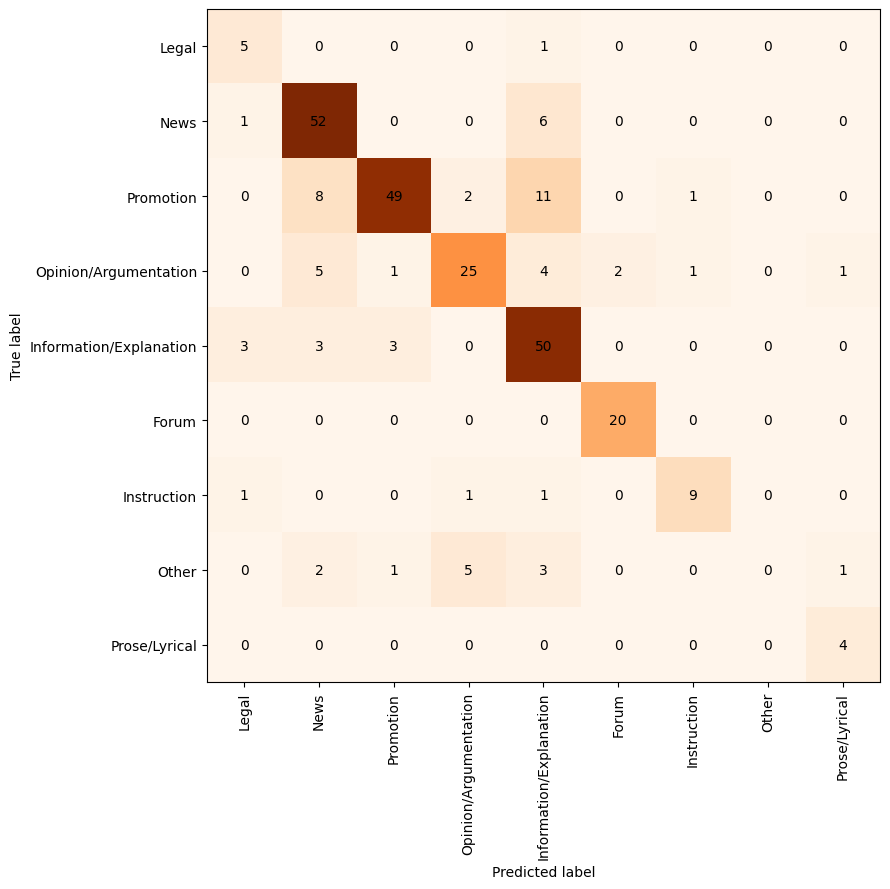

GPT-4o
en_ginco
Macro f1: 0.641, Micro f1: 0.747
                         precision    recall  f1-score   support

                  Forum       0.80      0.89      0.84        18
Information/Explanation       0.68      0.82      0.74        62
            Instruction       0.78      0.70      0.74        10
                  Legal       0.25      1.00      0.40         1
                   News       0.71      0.87      0.78        45
  Opinion/Argumentation       0.78      0.73      0.75        48
                  Other       0.00      0.00      0.00         9
              Promotion       0.93      0.65      0.76        57
          Prose/Lyrical       0.60      1.00      0.75         3

               accuracy                           0.75       253
              macro avg       0.61      0.74      0.64       253
           weighted avg       0.74      0.75      0.74       253



/home/tajak/miniconda3/envs/emma_main/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/tajak/miniconda3/envs/emma_main/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/tajak/miniconda3/envs/emma_main/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.cap

<Figure size 640x480 with 0 Axes>

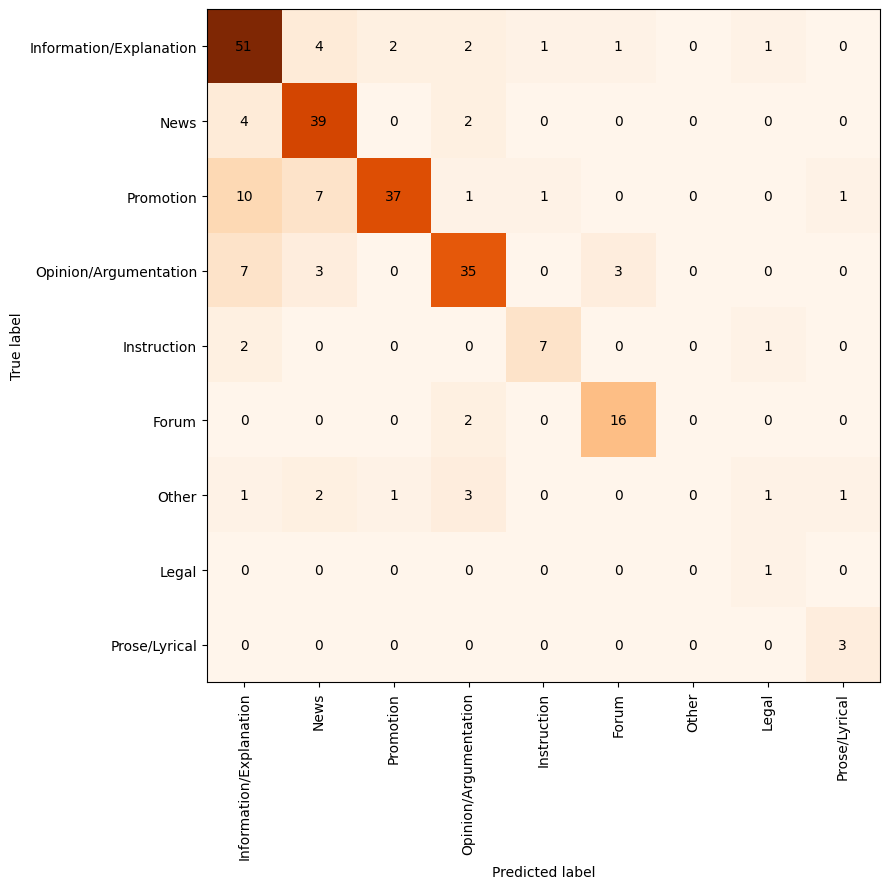

GPT-5
ginco
Macro f1: 0.719, Micro f1: 0.78
                         precision    recall  f1-score   support

                  Forum       0.95      1.00      0.98        20
Information/Explanation       0.77      0.80      0.78        59
            Instruction       0.85      0.92      0.88        12
                  Legal       0.67      0.67      0.67         6
                   News       0.72      0.95      0.82        59
  Opinion/Argumentation       0.77      0.59      0.67        39
                  Other       0.00      0.00      0.00        12
              Promotion       0.81      0.77      0.79        71
          Prose/Lyrical       0.80      1.00      0.89         4

               accuracy                           0.78       282
              macro avg       0.70      0.74      0.72       282
           weighted avg       0.75      0.78      0.76       282



/home/tajak/miniconda3/envs/emma_main/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/tajak/miniconda3/envs/emma_main/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/tajak/miniconda3/envs/emma_main/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.cap

<Figure size 640x480 with 0 Axes>

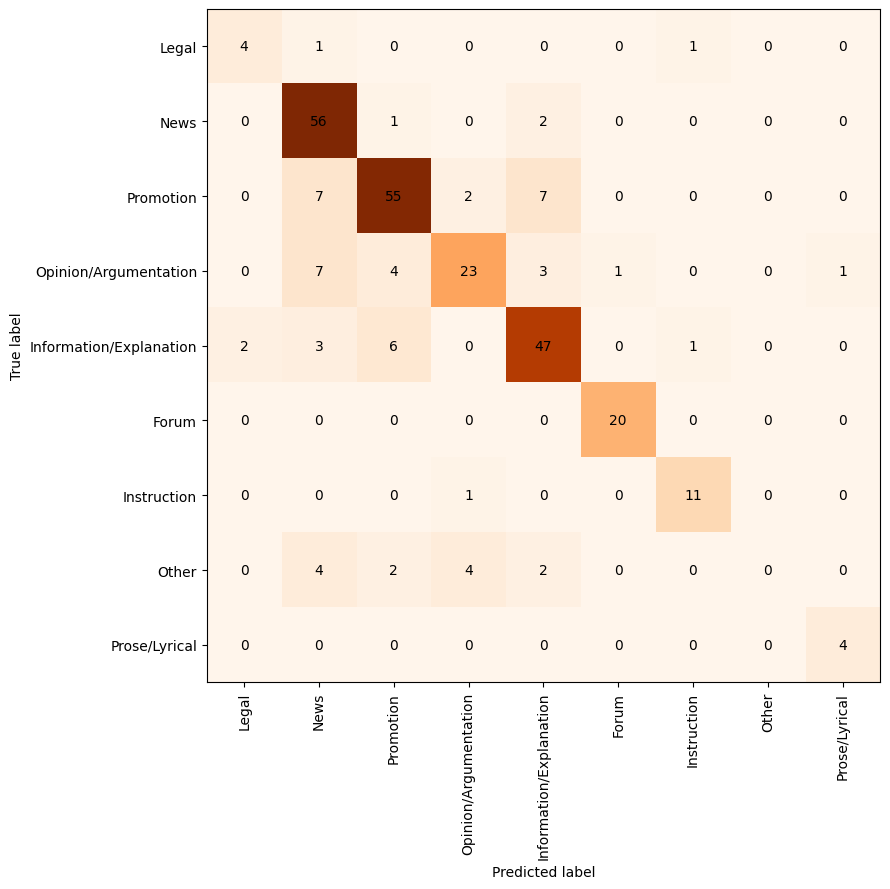

GPT-5
en_ginco
Macro f1: 0.703, Micro f1: 0.806
                         precision    recall  f1-score   support

                  Forum       0.89      0.89      0.89        18
Information/Explanation       0.82      0.79      0.80        62
            Instruction       0.80      0.80      0.80        10
                  Legal       0.33      1.00      0.50         1
                   News       0.72      0.91      0.80        45
  Opinion/Argumentation       0.95      0.77      0.85        48
                  Other       0.00      0.00      0.00         9
              Promotion       0.79      0.86      0.82        57
          Prose/Lyrical       0.75      1.00      0.86         3

               accuracy                           0.81       253
              macro avg       0.67      0.78      0.70       253
           weighted avg       0.79      0.81      0.79       253



/home/tajak/miniconda3/envs/emma_main/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/tajak/miniconda3/envs/emma_main/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/tajak/miniconda3/envs/emma_main/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.cap

<Figure size 640x480 with 0 Axes>

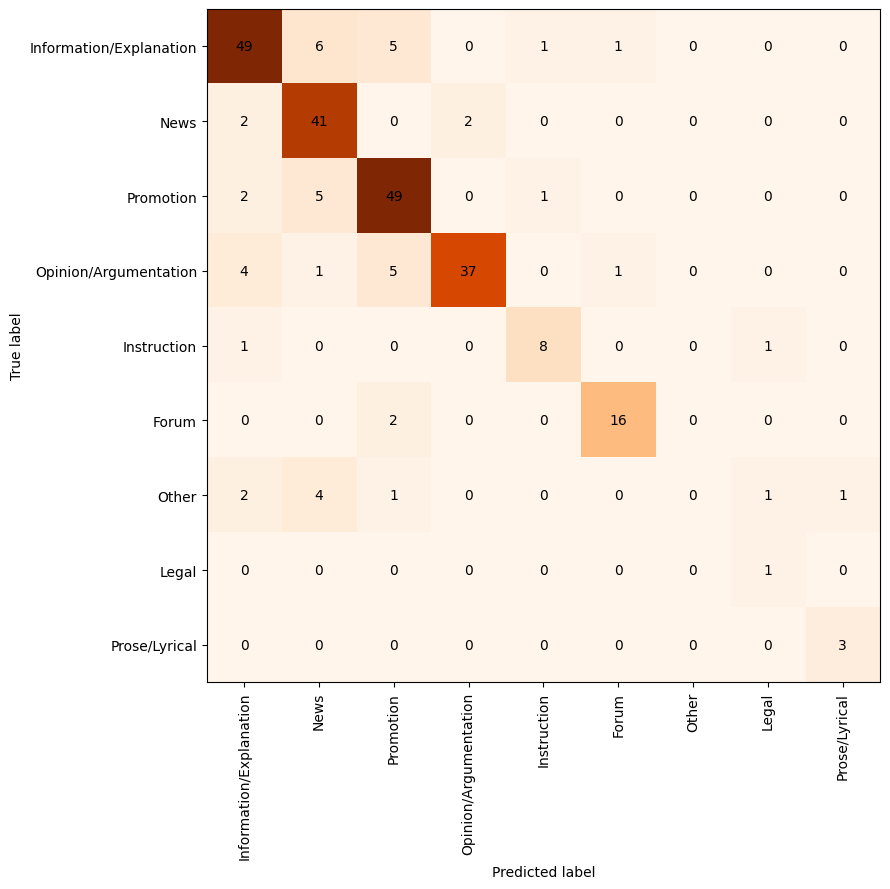

Gemini-2.5-Flash
ginco
Macro f1: 0.717, Micro f1: 0.762
                         precision    recall  f1-score   support

                  Forum       0.95      0.90      0.92        20
Information/Explanation       0.72      0.80      0.76        59
            Instruction       0.91      0.83      0.87        12
                  Legal       0.71      0.83      0.77         6
                   News       0.73      0.88      0.80        59
  Opinion/Argumentation       0.69      0.64      0.67        39
                  Other       0.00      0.00      0.00        12
              Promotion       0.79      0.76      0.78        71
          Prose/Lyrical       0.80      1.00      0.89         4

               accuracy                           0.76       282
              macro avg       0.70      0.74      0.72       282
           weighted avg       0.73      0.76      0.75       282



/home/tajak/miniconda3/envs/emma_main/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/tajak/miniconda3/envs/emma_main/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/tajak/miniconda3/envs/emma_main/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.cap

<Figure size 640x480 with 0 Axes>

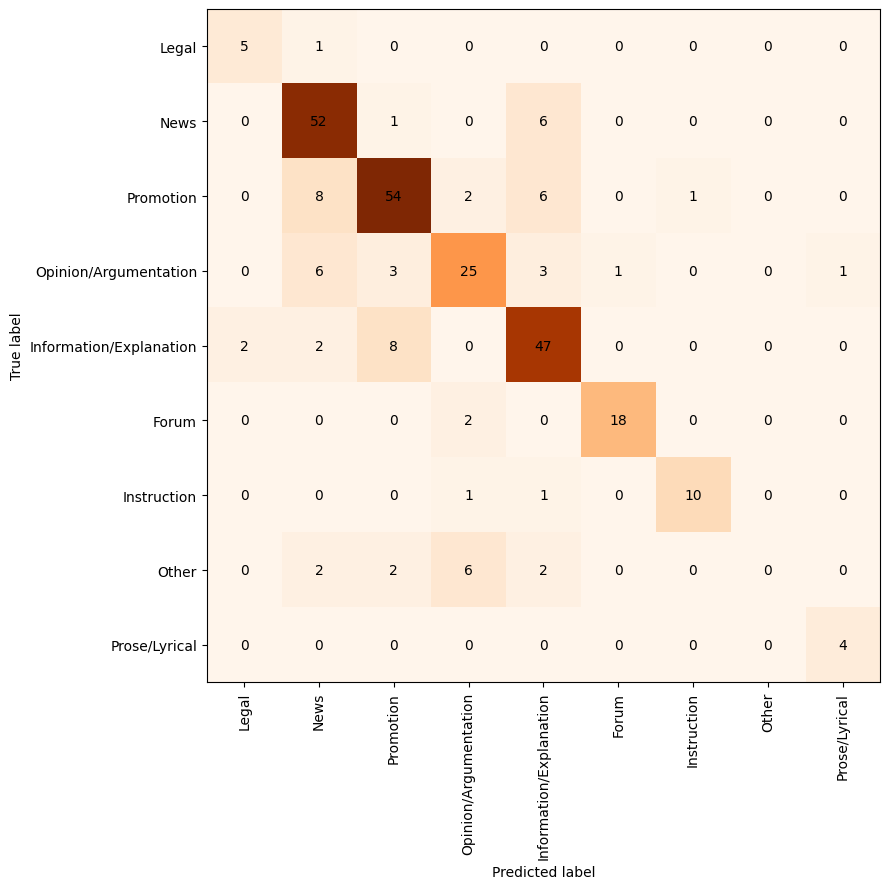

Gemini-2.5-Flash
en_ginco
Macro f1: 0.674, Micro f1: 0.783
                         precision    recall  f1-score   support

                  Forum       0.94      0.89      0.91        18
Information/Explanation       0.72      0.77      0.74        62
            Instruction       0.86      0.60      0.71        10
                  Legal       0.25      1.00      0.40         1
                   News       0.73      0.91      0.81        45
  Opinion/Argumentation       0.88      0.75      0.81        48
                  Other       0.00      0.00      0.00         9
              Promotion       0.82      0.82      0.82        57
          Prose/Lyrical       0.75      1.00      0.86         3

               accuracy                           0.78       253
              macro avg       0.66      0.75      0.67       253
           weighted avg       0.77      0.78      0.77       253



/home/tajak/miniconda3/envs/emma_main/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/tajak/miniconda3/envs/emma_main/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/tajak/miniconda3/envs/emma_main/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.cap

<Figure size 640x480 with 0 Axes>

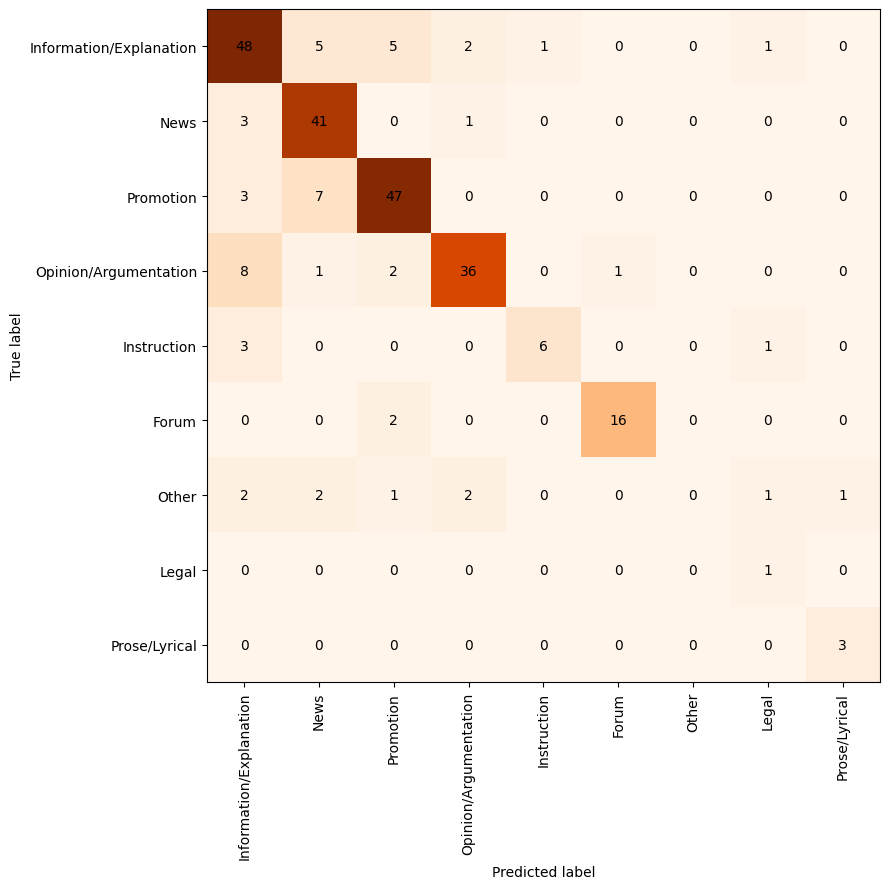

[{'micro_F1': 0.7588652482269503,
  'macro_F1': 0.6872640426228788,
  'dataset': 'ginco',
  'model': 'GPT-4o'},
 {'micro_F1': 0.7470355731225297,
  'macro_F1': 0.6410052984274959,
  'dataset': 'en_ginco',
  'model': 'GPT-4o'},
 {'micro_F1': 0.7801418439716312,
  'macro_F1': 0.7188944962559022,
  'dataset': 'ginco',
  'model': 'GPT-5'},
 {'micro_F1': 0.8063241106719368,
  'macro_F1': 0.7030373475102413,
  'dataset': 'en_ginco',
  'model': 'GPT-5'},
 {'micro_F1': 0.7624113475177305,
  'macro_F1': 0.7169412665166414,
  'dataset': 'ginco',
  'model': 'Gemini-2.5-Flash'},
 {'micro_F1': 0.782608695652174,
  'macro_F1': 0.6741031473948781,
  'dataset': 'en_ginco',
  'model': 'Gemini-2.5-Flash'}]

<Figure size 640x480 with 0 Axes>

In [31]:
# Calculate also the models performance on final labels

results = []

for model in ["GPT-4o", "GPT-5", "Gemini-2.5-Flash"]:
	print(model)
	print("ginco")
	cur_scores = evaluate(ginco, "Gold_X-GENRE", model, matrix=True)
	cur_scores["dataset"] = "ginco"
	cur_scores["model"] = model
	results.append(cur_scores)
	print(model)
	print("en_ginco")
	cur_scores = evaluate(en_ginco, "Gold_X-GENRE", model, matrix=True)
	cur_scores["dataset"] = "en_ginco"
	cur_scores["model"] = model
	results.append(cur_scores)

results

In [35]:
results_df = pd.DataFrame(results)
print(results_df[["model", "dataset", "macro_F1", "micro_F1"]].round(2).to_markdown(index=False))

| model            | dataset   |   macro_F1 |   micro_F1 |
|:-----------------|:----------|-----------:|-----------:|
| GPT-4o           | ginco     |       0.69 |       0.76 |
| GPT-4o           | en_ginco  |       0.64 |       0.75 |
| GPT-5            | ginco     |       0.72 |       0.78 |
| GPT-5            | en_ginco  |       0.7  |       0.81 |
| Gemini-2.5-Flash | ginco     |       0.72 |       0.76 |
| Gemini-2.5-Flash | en_ginco  |       0.67 |       0.78 |


Calculate agreement if gold label "Other" is removed.

In [9]:
print(ginco.shape)
ginco = ginco[ginco["Gold_X-GENRE"] != "Other"]
print(ginco.shape)

(282, 14)
(270, 14)


In [10]:
print(en_ginco.shape)
en_ginco = en_ginco[en_ginco["Gold_X-GENRE"] != "Other"]
print(en_ginco.shape)

(253, 11)
(244, 11)


In [13]:
calc_agreement(ginco, "ginco")

Number of instances:  270
Krippendorff's Alpha:  0.7893278953182089
Number of instances:  270
Krippendorff's Alpha:  0.7021010654127731
Number of instances:  270
Krippendorff's Alpha:  0.7034601256072994
Number of instances:  270
Krippendorff's Alpha:  0.7419575457584229
Number of instances:  270
Krippendorff's Alpha:  0.7434882001512693
Number of instances:  270
Krippendorff's Alpha:  0.7143760683760684
Number of instances:  270
Krippendorff's Alpha:  0.7205853608790611
ginco
| pair                    |   nominal Krippendorff Alpha |
|:------------------------|-----------------------------:|
| Ann1 & Ann2             |                     0.789328 |
| Ann2 & GPT-5            |                     0.743488 |
| Ann1 & GPT-5            |                     0.741958 |
| Ann2 & Gemini-2.5-Flash |                     0.720585 |
| Ann1 & Gemini-2.5-Flash |                     0.714376 |
| Ann2 & GPT-4o           |                     0.70346  |
| Ann1 & GPT-4o           |                   

In [12]:
calc_agreement(en_ginco, "enginco")

Number of instances:  244
Krippendorff's Alpha:  0.7703552342030808
Number of instances:  244
Krippendorff's Alpha:  0.7029425993311318
Number of instances:  244
Krippendorff's Alpha:  0.6748795193290635
Number of instances:  244
Krippendorff's Alpha:  0.7596173032693054
Number of instances:  244
Krippendorff's Alpha:  0.735303955180199
Number of instances:  244
Krippendorff's Alpha:  0.7330803689064558
Number of instances:  244
Krippendorff's Alpha:  0.749984284307357
enginco
| pair                    |   nominal Krippendorff Alpha |
|:------------------------|-----------------------------:|
| Ann1 & Ann2             |                     0.770355 |
| Ann1 & GPT-5            |                     0.759617 |
| Ann2 & Gemini-2.5-Flash |                     0.749984 |
| Ann2 & GPT-5            |                     0.735304 |
| Ann1 & Gemini-2.5-Flash |                     0.73308  |
| Ann1 & GPT-4o           |                     0.702943 |
| Ann2 & GPT-4o           |                   

GPT-5
ginco
Macro f1: 0.82, Micro f1: 0.815
                         precision    recall  f1-score   support

                  Forum       0.95      1.00      0.98        20
Information/Explanation       0.80      0.80      0.80        59
            Instruction       0.85      0.92      0.88        12
                  Legal       0.67      0.67      0.67         6
                   News       0.76      0.95      0.84        59
  Opinion/Argumentation       0.88      0.59      0.71        39
              Promotion       0.83      0.77      0.80        71
          Prose/Lyrical       0.80      1.00      0.89         4

               accuracy                           0.81       270
              macro avg       0.82      0.84      0.82       270
           weighted avg       0.82      0.81      0.81       270



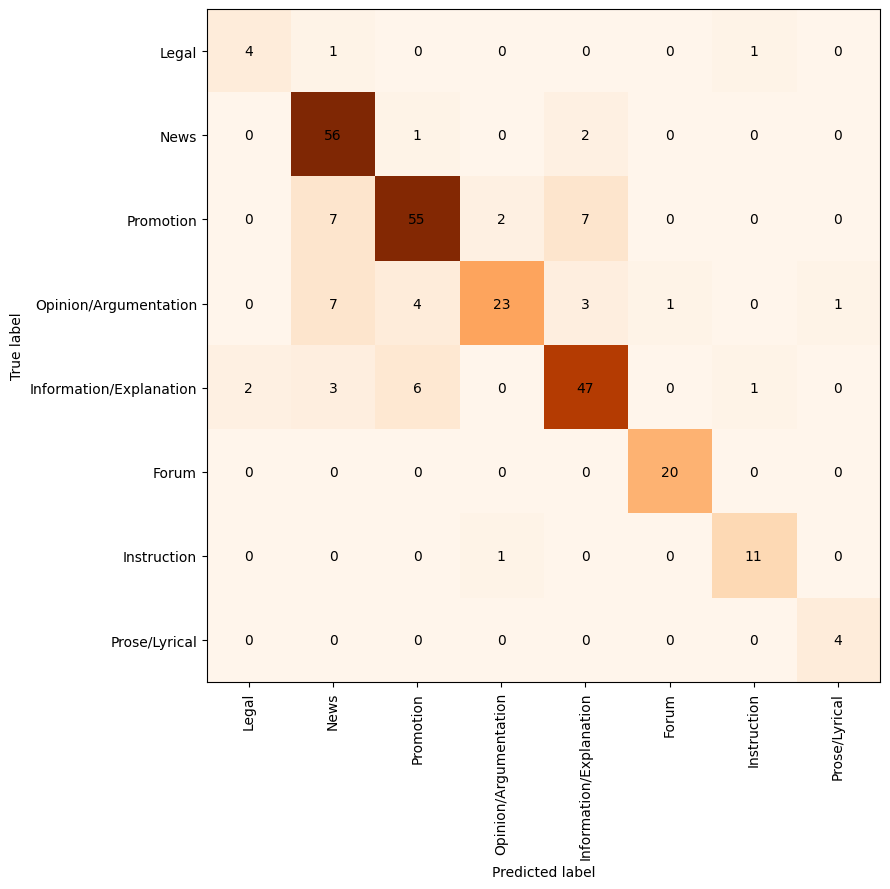

GPT-5
en_ginco
Macro f1: 0.836, Micro f1: 0.836
                         precision    recall  f1-score   support

                  Forum       0.89      0.89      0.89        18
Information/Explanation       0.84      0.79      0.82        62
            Instruction       0.80      0.80      0.80        10
                  Legal       0.50      1.00      0.67         1
                   News       0.77      0.91      0.84        45
  Opinion/Argumentation       0.95      0.77      0.85        48
              Promotion       0.80      0.86      0.83        57
          Prose/Lyrical       1.00      1.00      1.00         3

               accuracy                           0.84       244
              macro avg       0.82      0.88      0.84       244
           weighted avg       0.84      0.84      0.84       244



<Figure size 640x480 with 0 Axes>

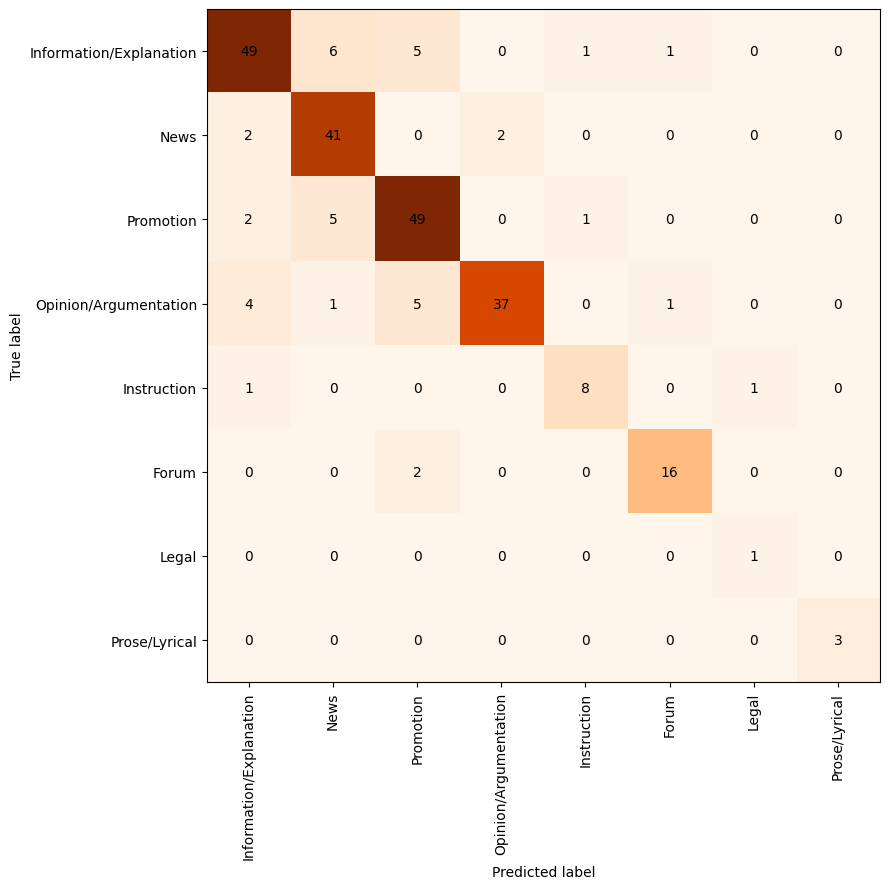

| model   | dataset   |   macro_F1 |   micro_F1 |
|:--------|:----------|-----------:|-----------:|
| GPT-5   | ginco     |       0.82 |       0.81 |
| GPT-5   | en_ginco  |       0.84 |       0.84 |


<Figure size 640x480 with 0 Axes>

In [14]:
# Calculate also the models performance on final labels

results = []

for model in ["GPT-5"]:
	print(model)
	print("ginco")
	cur_scores = evaluate(ginco, "Gold_X-GENRE", model, matrix=True)
	cur_scores["dataset"] = "ginco"
	cur_scores["model"] = model
	results.append(cur_scores)
	print(model)
	print("en_ginco")
	cur_scores = evaluate(en_ginco, "Gold_X-GENRE", model, matrix=True)
	cur_scores["dataset"] = "en_ginco"
	cur_scores["model"] = model
	results.append(cur_scores)

results_df = pd.DataFrame(results)
print(results_df[["model", "dataset", "macro_F1", "micro_F1"]].round(2).to_markdown(index=False))